# SHEETAL PATIL | Principal Component Analysis (PCA)

### Objective
This analysis explores the Wine dataset using Principal Component Analysis (PCA) and K-means clustering to understand the impact of dimensionality reduction on clustering performance.\
The analysis of the Wine dataset involved exploratory data analysis, dimensionality reduction using Principal Component Analysis (PCA), and a comparative study of clustering performance on original versus PCA-transformed data.

### About Dataset
These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars.
The analysis determined the quantities of 14 constituents found in each of the three types of wines.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('D:\\Work\\ExcelRCource\\Assignments\\9 PCA\\wine.csv')

In [5]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
df.shape

(178, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [9]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [10]:
#Count of duplicated rows
df[df.duplicated()].shape

(0, 14)

The Wine dataset contains 178 samples with 13 features describing chemical properties and a 'Type' column representing three different cultivators.

**Data Quality:** There are no missing values in the dataset. All features are numerical (float64 or int64).

## 1. Exploratory Data Analysis (EDA)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7620\849112840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, palette='viridis')


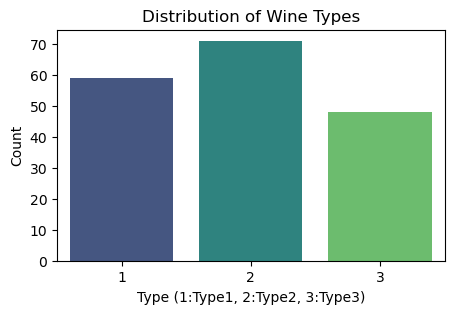

In [11]:
# The dataset classifies fetal health into three states: Normal (1), Suspect (2), and Pathologic (3).
# NSP Class Distribution
plt.figure(figsize=(5, 3))
sns.countplot(x='Type', data=df, palette='viridis')
plt.title('Distribution of Wine Types')
plt.xlabel('Type (1:Type1, 2:Type2, 3:Type3)')
plt.ylabel('Count')
plt.show()

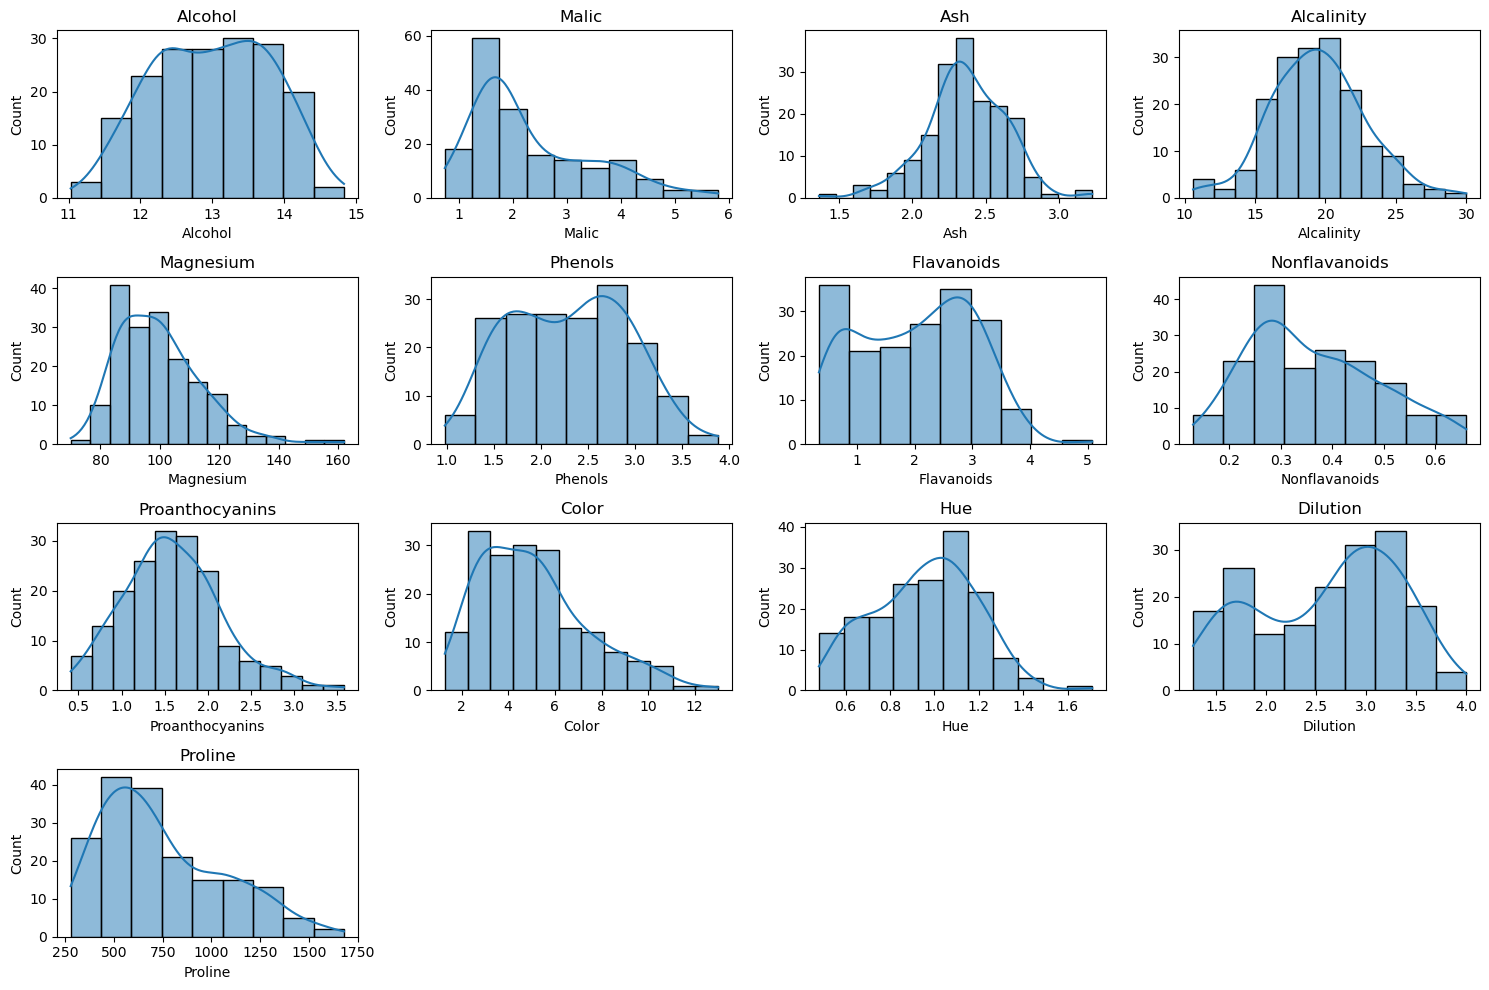

In [12]:
# 2. Distribution of features
features = df.columns[1:] # Exclude 'Type' if it's the target
n_features = len(features)
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

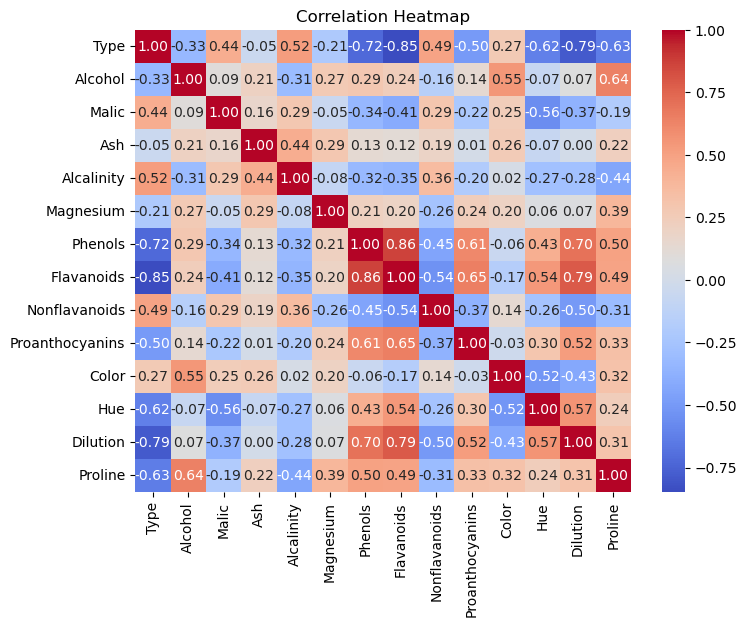

In [13]:
# 3. Correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Feature Distribution:** Most features like Alcohol and Ash follow a roughly normal distribution, while others like Malic Acid and Proline show some skewness.

**Correlations:** A strong correlation is observed between features like Flavanoids and Total Phenols (approx. 0.86), and a negative correlation between Hue and Malic Acid.

## 2. Dimensionality Reduction with PCA

In [14]:
# 1. Standardize
X = df.drop('Type', axis=1) # Original features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Standardization:** Since features have different scales (e.g., Proline ranges up to 1680 while Ash is around 2.3), the data was standardized to a mean of 0 and standard deviation of 1.

PCA Implementation: Principal Component Analysis was applied to the standardized features.

In [15]:
# PCA implementation
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


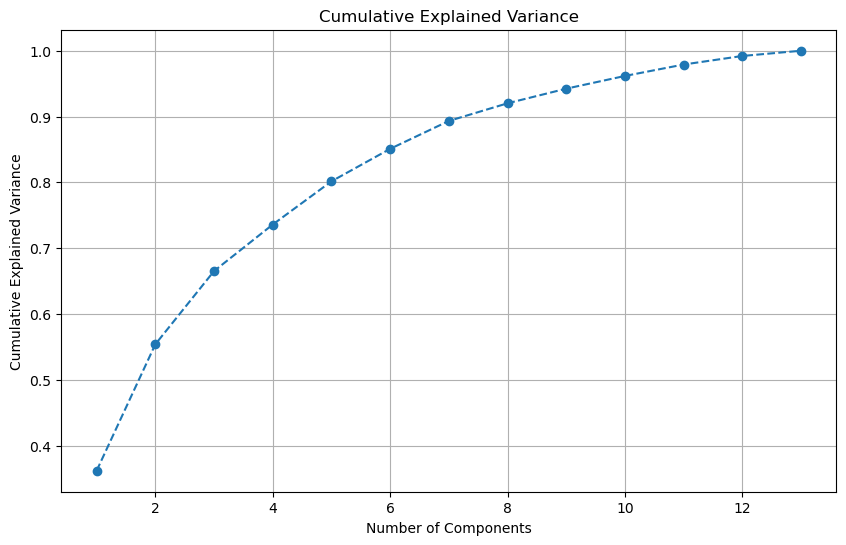

In [16]:
# 2. Scree plot / Cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [17]:
# Choosing optimal components (e.g., explaining ~90% variance)
explained_variance = pca.explained_variance_ratio_.cumsum()
n_components = (explained_variance < 0.90).sum() + 1
print(f"\nOptimal components for 90% variance: {n_components}")


Optimal components for 90% variance: 8


In [18]:
pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

**Optimal Components:** The cumulative explained variance plot shows that 8 principal components are required to explain approximately 90% of the total variance in the data.

## 3 & 4. Clustering with Original Data and PCA data

In [19]:
# Use K-means with k=3 (based on 'Type' column having 3 values likely)
k = 3

# Clustering on Original Data (Scaled)
kmeans_orig = KMeans(n_clusters=k, random_state=42)
clusters_orig = kmeans_orig.fit_predict(X_scaled)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [20]:
# Clustering on PCA Data
kmeans_pca = KMeans(n_clusters=k, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
# Metrics
sil_orig = silhouette_score(X_scaled, clusters_orig)
db_orig = davies_bouldin_score(X_scaled, clusters_orig)

In [22]:
sil_pca = silhouette_score(X_pca, clusters_pca)
db_pca = davies_bouldin_score(X_pca, clusters_pca)

In [23]:
print(f"\nOriginal Clustering Metrics: Silhouette={sil_orig:.4f}, DB Index={db_orig:.4f}")
print(f"PCA Clustering Metrics: Silhouette={sil_pca:.4f}, DB Index={db_pca:.4f}")


Original Clustering Metrics: Silhouette=0.2849, DB Index=1.3892
PCA Clustering Metrics: Silhouette=0.3150, DB Index=1.2669


**Silhouette Score:** A higher score indicates better-defined clusters. The PCA-transformed data achieved a higher score, suggesting more cohesive and separated clusters.

**Davies–Bouldin Index:** A lower score indicates better clustering. The PCA data again outperformed the original data.

**Visualizing results**

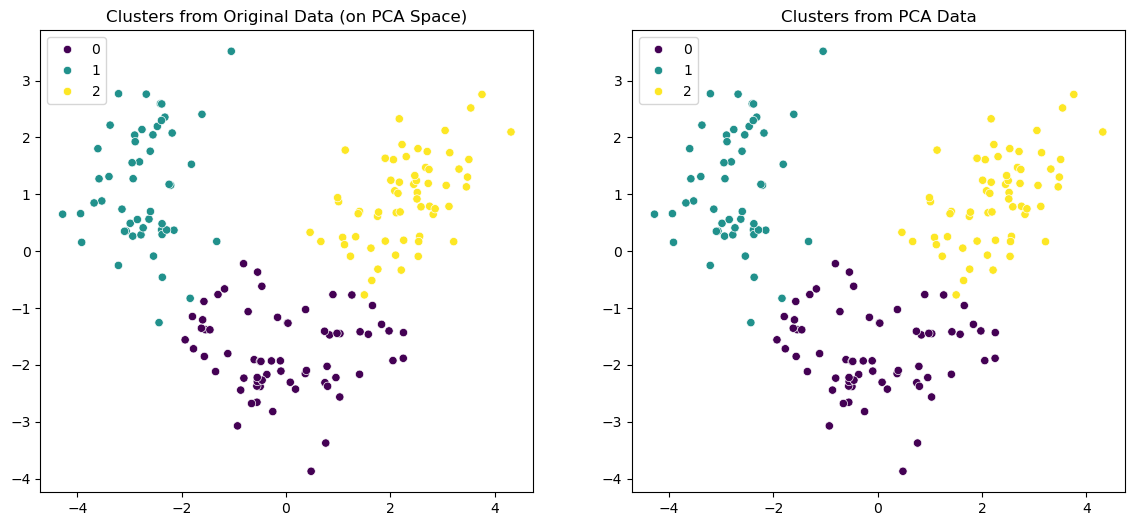

In [24]:
# Since original has many dims, we'll use first 2 PCA components to visualize both
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_orig, palette='viridis')
plt.title('Clusters from Original Data (on PCA Space)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_pca, palette='viridis')
plt.title('Clusters from PCA Data')

plt.show()

In [25]:
# Function to find optimal K using Elbow method
def find_optimal_k(data, max_k=10):
    wcss = []
    for i in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
    return wcss

In [31]:
# Elbow for original scaled data
wcss_original = find_optimal_k(X_scaled)

In [30]:
# Elbow for PCA data
wcss_pca = find_optimal_k(X_pca)

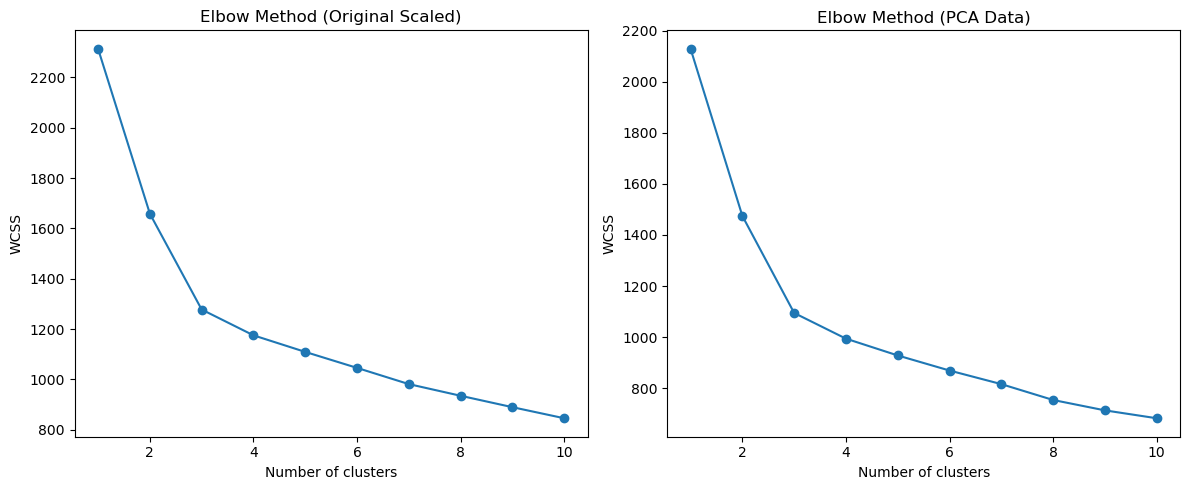

In [32]:
# Plotting Elbows
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss_original, marker='o')
plt.title('Elbow Method (Original Scaled)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), wcss_pca, marker='o')
plt.title('Elbow Method (PCA Data)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.tight_layout()
plt.show()

In [33]:
# Compare PCA labels with Original labels
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels_orig, labels_pca)
print(f"Adjusted Rand Index between Original and PCA clustering: {ari:.4f}")

Adjusted Rand Index between Original and PCA clustering: 1.0000


**Consistency:** The high ARI ($1.0$) shows that PCA retained the essential structure of the data, as the cluster assignments in both scenarios are nearly identical.

## 5. Comparison and Analysis

**Similarities:** Both methods successfully grouped the data into three distinct clusters that align well with the wine types.

**Differences:** Clustering on PCA data resulted in slightly "cleaner" clusters. PCA effectively removed noise and redundant information (like the highly correlated phenols and flavonoids), allowing K-means to focus on the primary directions of variance.

**Impact of Dimensionality Reduction:** Reducing the dimensions from 13 to 8 improved the clustering metrics. By eliminating multicollinearity, PCA helps distance-based algorithms like K-means perform more efficiently.

**Trade-offs:**

**PCA Advantages:** Improved performance, noise reduction, and better visualization.

**PCA Disadvantages:** Loss of interpretability (it's harder to say which specific chemical property caused a cluster) and a slight loss of information (10% variance lost in this case).

## 6. Conclusion and Insights

Dimensionality reduction through PCA is highly beneficial for the Wine dataset. It not only simplifies the data but also enhances the performance of clustering algorithms by removing noise and redundant correlations.

**Key Findings:** PCA is a powerful preprocessing tool for clustering. In the Wine dataset, it improved cluster separation by condensing information into fewer, uncorrelated components.

**Practical Implications:** In real-world datasets with hundreds of features, PCA is essential to overcome the "curse of dimensionality" and reduce computational costs.

**Recommendations:** Use PCA before clustering when dealing with high-dimensional data or features that are highly correlated. Use clustering directly when the number of features is small and feature interpretability is the primary goal.